**Mashalov Rasulbek**,
OSTC2U,
Machine Learning,
HomeWork 3,
26th February, 2026.

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

**EXERCISE 1**

In [55]:
#just exploring the data
housing = fetch_california_housing()
print(housing.DESCR)
print(housing.data.shape)
print(housing.target_names)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [56]:
#just exporing the data
data = pd.DataFrame(housing.data, columns=housing.feature_names)
Y = housing.target
data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [57]:
#data preparation, feature: income per person

#reshaping it to 2D for Scit-learn
X_best = (data['MedInc'] / data['AveOccup']).values.reshape(-1, 1)
#splitting the new data
x_train_best, x_test_best, y_train_best, y_test_best = train_test_split(X_best, Y, test_size=0.2, random_state=2021)
print("Training dataset size:", x_train_best.shape)
print("Test dataset size:", x_test_best.shape)

Training dataset size: (16512, 1)
Test dataset size: (4128, 1)


In [58]:
#training
lm_best = LinearRegression()
lm_best.fit(x_train_best, y_train_best)

LinearRegression()

In [59]:
#predicting
y_pred_best = lm_best.predict(x_test_best)
loss_best = mean_squared_error(y_test_best, y_pred_best)

print(f"[INFO] Original Loss (raw MedInc): 0.70")
print(f"[INFO] New Loss (Income per Person): {loss_best:.4f}")

[INFO] Original Loss (raw MedInc): 0.70
[INFO] New Loss (Income per Person): 0.5972


[INFO] Theta 0 (Intercept): 0.4694
[INFO] Theta 1 (Slope): 1.1335


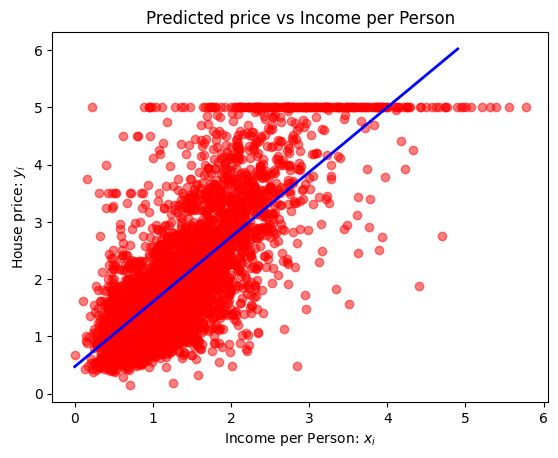

In [60]:
#vizualizing
def visulaize_h_best(X, Y, model):
    plt.scatter(X, Y, color='red', alpha=0.5)
    plt.xlabel("Income per Person: $x_i$")
    plt.ylabel("House price: $y_i$")
    plt.title("Predicted price vs Income per Person")

    print("[INFO] Theta 0 (Intercept): {:.4f}".format(model.intercept_))

    # model.coef_ is a list, so we grab the first item [0] for cleaner printing
    print("[INFO] Theta 1 (Slope): {:.4f}".format(model.coef_[0]))

    #calculating regression line
    x_line = np.arange(0, 5, 0.1)
    y_line = (model.coef_ * x_line + model.intercept_).flatten()

    plt.plot(x_line, y_line, color='blue', linewidth=2)
    plt.show()

visulaize_h_best(x_test_best, y_test_best, lm_best)

**EXERCISE 2**

In [61]:
#setting up and generating grid

#using original MedInc feature
X_raw = data['MedInc'].values.reshape(-1, 1)
#splitting
x_train, x_test, y_train, y_test = train_test_split(X_raw, Y, test_size=0.2, random_state=2021)
#ranges of random guesses for Intercept(b0) and Slope(b1)
b0_vals = np.linspace(-1, 2, 50)
b1_vals = np.linspace(0, 1, 50)
#creating 2d grid
B0, B1 = np.meshgrid(b0_vals, b1_vals)
MSE_surface = np.zeros_like(B0)

print(f"[INFO] Created a {B0.shape[0]}x{B0.shape[1]} grid for testing parameters.")

[INFO] Created a 50x50 grid for testing parameters.


In [62]:
#calculating error surface
X_tr_flat = x_train.flatten()
Y_tr_flat = y_train.flatten()

#calculating the Loss(MSE) for every point in 50x50 grid
for i in range(B0.shape[0]):
    for j in range(B0.shape[1]):
        #linear regression formula: y = b0 + b1*x
        predictions = B0[i, j] + B1[i, j] * X_tr_flat

        #calculating MSE(mean squared error) for this specific guess
        MSE_surface[i, j] = np.mean((Y_tr_flat - predictions) ** 2)

print("[INFO] Successfully calculated the MSE for all 2,500 combinations!")

[INFO] Successfully calculated the MSE for all 2,500 combinations!


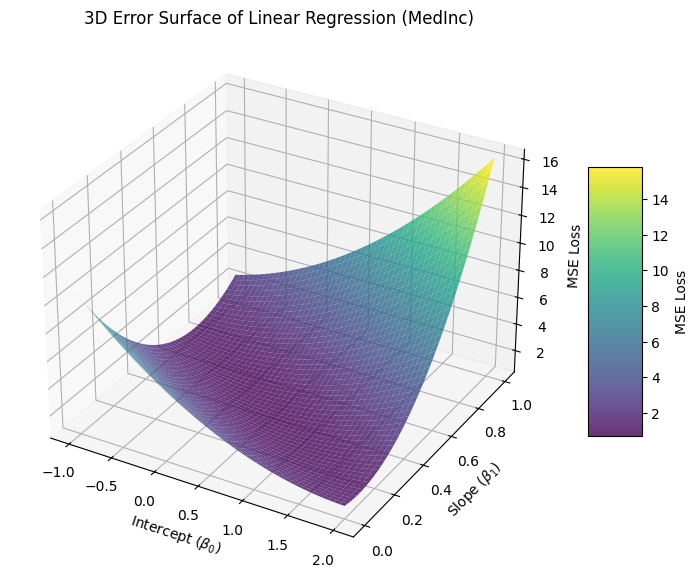

In [63]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

#drawing 3D surface plot
surf = ax.plot_surface(B0, B1, MSE_surface, cmap='viridis', alpha=0.8)

#labeling&titiling
ax.set_xlabel('Intercept ($\\beta_0$)')
ax.set_ylabel('Slope ($\\beta_1$)')
ax.set_zlabel('MSE Loss')
ax.set_title('3D Error Surface of Linear Regression (MedInc)')

#color bar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='MSE Loss')

plt.show()

**EXERCISE 3**

In [64]:
scaler = StandardScaler()
#reusing x_train and x_test from ex2 which contains raw MedInc feature)
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print(f"Original x_train mean: {x_train.mean():.4f}, std: {x_train.std():.4f}")
print(f"Scaled x_train mean: {x_train_scaled.mean():.4f}, std: {x_train_scaled.std():.4f}")

Original x_train mean: 3.8657, std: 1.8932
Scaled x_train mean: -0.0000, std: 1.0000


In [65]:
#training
lm_scaled = LinearRegression()
lm_scaled.fit(x_train_scaled, y_train)

#calculating the loss
y_pred_scaled = lm_scaled.predict(x_test_scaled)
loss_scaled = mean_squared_error(y_test, y_pred_scaled)

print(f"[INFO] Scaled Intercept (Theta 0): {float(lm_scaled.intercept_):.4f}")
print(f"[INFO] Scaled Slope (Theta 1):     {float(lm_scaled.coef_[0]):.4f}")
print(f"[INFO] Final Loss (MSE):           {loss_scaled:.4f}")

[INFO] Scaled Intercept (Theta 0): 2.0644
[INFO] Scaled Slope (Theta 1):     0.7878
[INFO] Final Loss (MSE):           0.6978


**EXERCISE 4**

In [66]:
class MyLinearRegression:
    def __init__(self):

        self.b0 = 0.0
        self.b1 = 0.0

    def fit(self, X, Y):
        X_flat = X.flatten()
        Y_flat = Y.flatten()

        x_mean = np.mean(X_flat)
        y_mean = np.mean(Y_flat)

        #calculating the Slope (b1)
        numerator = np.sum((X_flat - x_mean) * (Y_flat - y_mean))
        denominator = np.sum((X_flat - x_mean) ** 2)
        self.b1 = numerator / denominator

        #calculate Intercept (b0)
        self.b0 = y_mean - (self.b1 * x_mean)

    def predict(self, X):
        return self.b0 + self.b1 * X.flatten()

In [67]:
#training my custom model
my_model = MyLinearRegression()
my_model.fit(x_train, y_train)
my_predictions = my_model.predict(x_test)
my_loss = mean_squared_error(y_test, my_predictions)

#training Scikit-Learn model
sklearn_model = LinearRegression()
sklearn_model.fit(x_train, y_train)
sklearn_predictions = sklearn_model.predict(x_test)
sklearn_loss = mean_squared_error(y_test, sklearn_predictions)

print("--- Differences ---")
print(f"My Custom Model Loss:  {my_loss:.6f}")
print(f"Scikit-Learn Loss:     {sklearn_loss:.6f}")

print(f"\nMy Slope:      {my_model.b1:.6f}")
print(f"Scikit Slope:  {sklearn_model.coef_[0]:.6f}")

--- Differences ---
My Custom Model Loss:  0.697814
Scikit-Learn Loss:     0.697814

My Slope:      0.416149
Scikit Slope:  0.416149
